In [19]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

### Початкові параметри та фіксація випадковості

In [20]:
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

### Завантаження та попередня обробка даних

In [21]:
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=seed,
    stratify=y_train_full
)

y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (40000, 32, 32, 3) (40000,)
Validation: (10000, 32, 32, 3) (10000,)
Test: (10000, 32, 32, 3) (10000,)


### Візуалізація прикладів з навчального набору

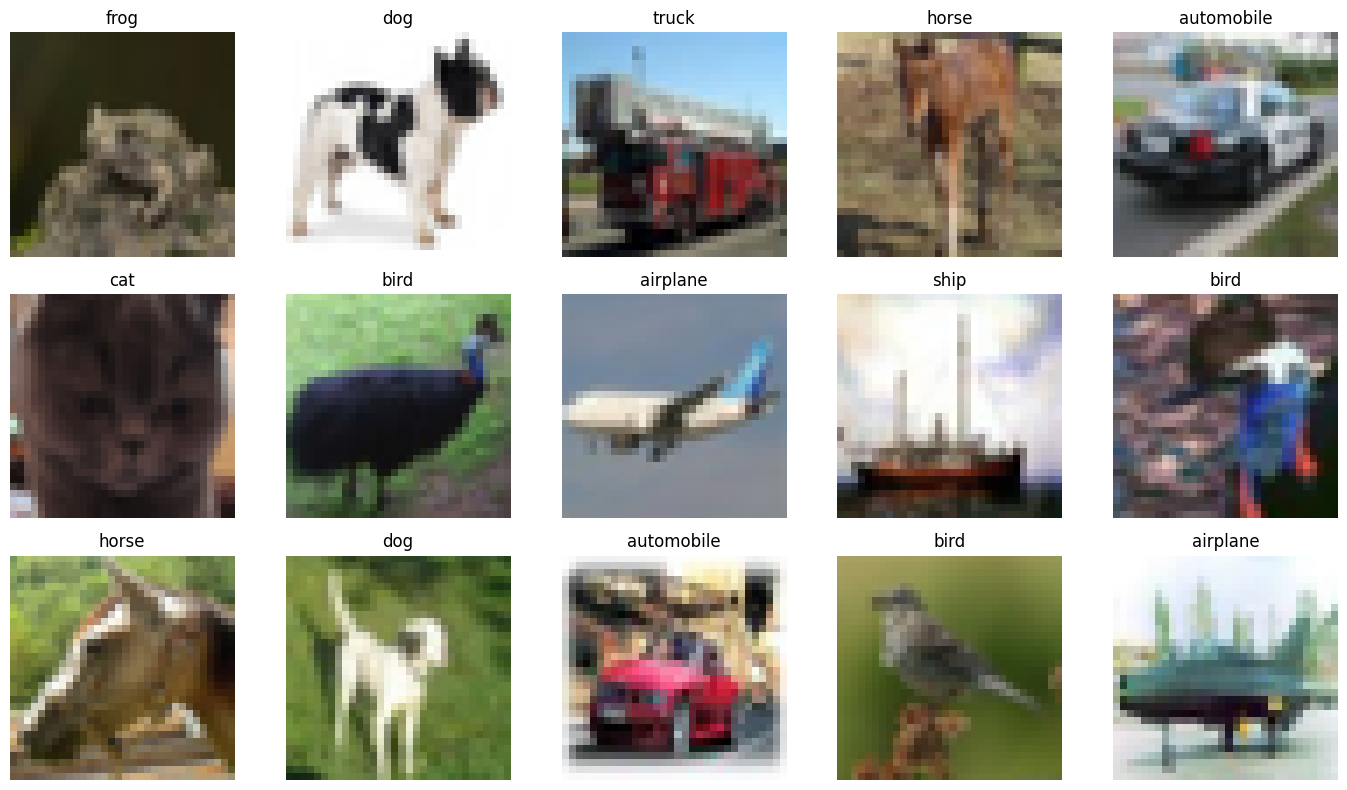

In [22]:
plt.figure(figsize=(14, 8))

indices = np.random.choice(len(x_train), 15, replace=False)

for i, idx in enumerate(indices, 1):
    plt.subplot(3, 5, i)
    plt.imshow(x_train[idx])
    plt.title(class_names[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Функція навчання моделі та оцінювання якості

In [23]:
def build_model(
    filters1=32,
    filters2=64,
    activation="relu",
    use_dropout=False,
    use_batchnorm=False
):
    model = Sequential()

    model.add(Input(shape=(32, 32, 3)))

    model.add(Conv2D(filters1, (3, 3), padding="same"))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation(activation))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(filters2, (3, 3), padding="same"))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation(activation))
    model.add(MaxPooling2D((2, 2)))

    if use_dropout:
        model.add(Dropout(0.25))

    model.add(Flatten())

    model.add(Dense(128))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation(activation))

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



def count_parameters(model):
    return model.count_params()

### Функція навчання моделі та оцінювання якості

In [24]:
def train_and_evaluate(model, x_train, y_train_cat, x_val, y_val_cat, x_test, y_test_cat):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train_cat,
        validation_data=(x_val, y_val_cat),
        epochs=12,
        batch_size=128,
        callbacks=[early_stop],
        verbose=1
    )

    training_time = time.time() - start_time

    test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
    predictions = np.argmax(model.predict(x_test, verbose=0), axis=1)

    return history, test_loss, test_accuracy, predictions, training_time

### Візуалізація процесу навчання моделі

In [25]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Таблиця для результатів

In [26]:
results = []
all_models = {}
all_predictions = {}

------

### Базова модель (Baseline)

In [27]:
print("Baseline model")

baseline_model = build_model(
    filters1=32,
    filters2=64,
    activation="relu",
    use_dropout=False,
    use_batchnorm=False
)

baseline_model.summary()

Baseline model


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

### Навчання базової моделі та аналіз результатів

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.4483 - loss: 1.5410 - val_accuracy: 0.5636 - val_loss: 1.2537
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.5868 - loss: 1.1733 - val_accuracy: 0.6159 - val_loss: 1.1124
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.6384 - loss: 1.0309 - val_accuracy: 0.6515 - val_loss: 1.0250
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.6733 - loss: 0.9373 - val_accuracy: 0.6611 - val_loss: 0.9928
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7013 - loss: 0.8677 - val_accuracy: 0.6748 - val_loss: 0.9555
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7226 - loss: 0.8078 - val_accuracy: 0.6819 - val_loss: 0.9373
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7400 - loss: 0.7578 - val_accuracy: 0.6843 - val_loss: 0.9330
Epoch 8/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7581 - loss: 0.7078 - 

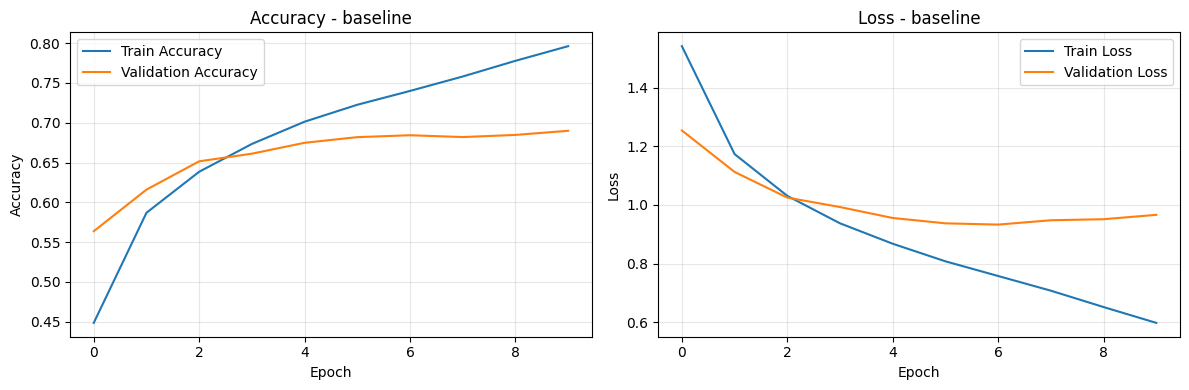

Test accuracy: 0.6843
Training time: 141.76 sec


In [28]:
baseline_history, baseline_test_loss, baseline_test_accuracy, baseline_predictions, baseline_time = train_and_evaluate(
    baseline_model,
    x_train, y_train_cat,
    x_val, y_val_cat,
    x_test, y_test_cat
)

plot_history(baseline_history, "baseline")

results.append({
    "experiment": "baseline",
    "description": "Base CNN with ReLU",
    "parameters": count_parameters(baseline_model),
    "test_loss": baseline_test_loss,
    "test_accuracy": baseline_test_accuracy,
    "best_val_accuracy": max(baseline_history.history["val_accuracy"]),
    "epochs_ran": len(baseline_history.history["loss"]),
    "training_time_sec": baseline_time
})

all_models["baseline"] = baseline_model
all_predictions["baseline"] = baseline_predictions

print("Test accuracy:", round(baseline_test_accuracy, 4))
print("Training time:", round(baseline_time, 2), "sec")

### Експеримент 1. Збільшення кількості фільтрів

In [29]:
print("Experiment 1 - more filters")

exp1_model = build_model(
    filters1=64,
    filters2=128,
    activation="relu",
    use_dropout=False,
    use_batchnorm=False
)

exp1_model.summary()

Experiment 1 - more filters


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,125,642 (4.29 MB)

 Trainable params: 1,125,642 (4.29 MB)

 Non-trainable params: 0 (0.00 B)

### Навчання моделі та аналіз результатів

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - accuracy: 0.4611 - loss: 1.5082 - val_accuracy: 0.5797 - val_loss: 1.1932
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.6134 - loss: 1.1011 - val_accuracy: 0.6430 - val_loss: 1.0339
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.6669 - loss: 0.9530 - val_accuracy: 0.6600 - val_loss: 0.9896
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.7029 - loss: 0.8568 - val_accuracy: 0.6714 - val_loss: 0.9630
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.7303 - loss: 0.7804 - val_accuracy: 0.6821 - val_loss: 0.9371
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.7562 - loss: 0.7107 - val_accuracy: 0.6822 - val_loss: 0.9362
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7785 - loss: 0.6449 - val_accuracy: 0.6909 - val_loss: 0.9200
Epoch 8/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.7998 - loss: 0

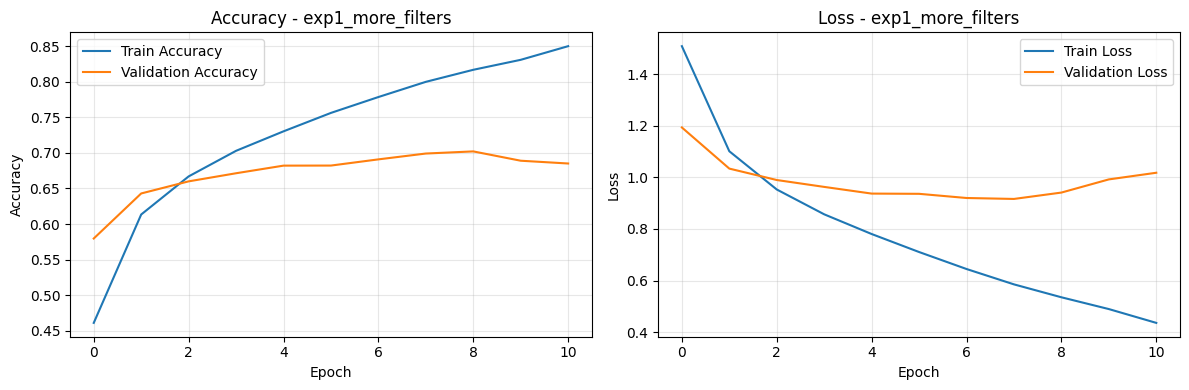

Test accuracy: 0.6957
Training time: 402.49 sec


In [30]:
exp1_history, exp1_test_loss, exp1_test_accuracy, exp1_predictions, exp1_time = train_and_evaluate(
    exp1_model,
    x_train, y_train_cat,
    x_val, y_val_cat,
    x_test, y_test_cat
)

plot_history(exp1_history, "exp1_more_filters")

results.append({
    "experiment": "exp1_more_filters",
    "description": "Increase number of filters: 64 and 128",
    "parameters": count_parameters(exp1_model),
    "test_loss": exp1_test_loss,
    "test_accuracy": exp1_test_accuracy,
    "best_val_accuracy": max(exp1_history.history["val_accuracy"]),
    "epochs_ran": len(exp1_history.history["loss"]),
    "training_time_sec": exp1_time
})

all_models["exp1_more_filters"] = exp1_model
all_predictions["exp1_more_filters"] = exp1_predictions

print("Test accuracy:", round(exp1_test_accuracy, 4))
print("Training time:", round(exp1_time, 2), "sec")

### Експеримент 2. Використання функції активації Sigmoid

In [31]:
print("Experiment 2 - sigmoid")

exp2_model = build_model(
    filters1=32,
    filters2=64,
    activation="sigmoid",
    use_dropout=False,
    use_batchnorm=False
)

exp2_model.summary()

Experiment 2 - sigmoid


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

### Навчання моделі та аналіз результатів

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.1428 - loss: 2.2625 - val_accuracy: 0.2379 - val_loss: 2.0590
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.2933 - loss: 1.9536 - val_accuracy: 0.3153 - val_loss: 1.8804
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.3474 - loss: 1.8198 - val_accuracy: 0.3625 - val_loss: 1.7800
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.3882 - loss: 1.7160 - val_accuracy: 0.3953 - val_loss: 1.6938
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.4203 - loss: 1.6331 - val_accuracy: 0.4189 - val_loss: 1.6273
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.4399 - loss: 1.5741 - val_accuracy: 0.4336 - val_loss: 1.5878
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.4559 - loss: 1.5303 - val_accuracy: 0.4466 - val_loss: 1.5539
Epoch 8/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.4686 - loss: 1.4941 - 

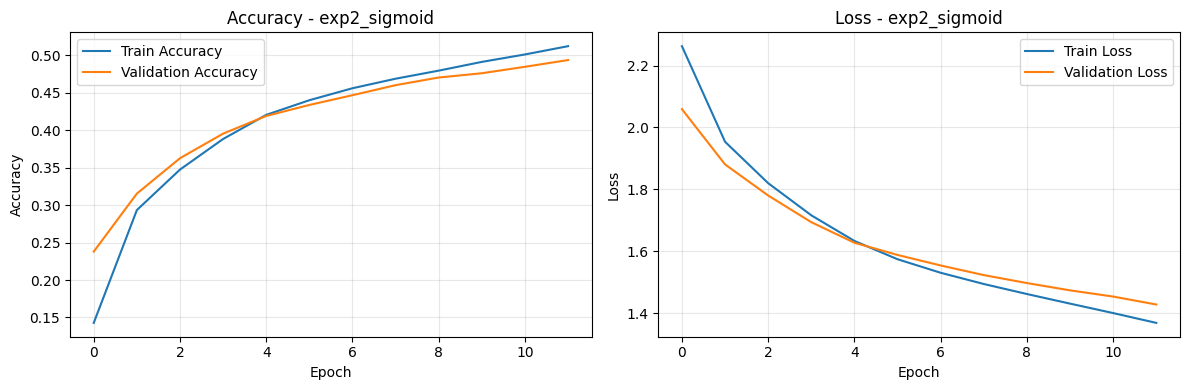

Test accuracy: 0.4961
Training time: 212.47 sec


In [32]:
exp2_history, exp2_test_loss, exp2_test_accuracy, exp2_predictions, exp2_time = train_and_evaluate(
    exp2_model,
    x_train, y_train_cat,
    x_val, y_val_cat,
    x_test, y_test_cat
)

plot_history(exp2_history, "exp2_sigmoid")

results.append({
    "experiment": "exp2_sigmoid",
    "description": "Replace ReLU with Sigmoid",
    "parameters": count_parameters(exp2_model),
    "test_loss": exp2_test_loss,
    "test_accuracy": exp2_test_accuracy,
    "best_val_accuracy": max(exp2_history.history["val_accuracy"]),
    "epochs_ran": len(exp2_history.history["loss"]),
    "training_time_sec": exp2_time
})

all_models["exp2_sigmoid"] = exp2_model
all_predictions["exp2_sigmoid"] = exp2_predictions

print("Test accuracy:", round(exp2_test_accuracy, 4))
print("Training time:", round(exp2_time, 2), "sec")

### Експеримент 3. Використання Dropout

In [33]:
print("Experiment 3 - dropout")

exp3_model = build_model(
    filters1=32,
    filters2=64,
    activation="relu",
    use_dropout=True,
    use_batchnorm=False
)

exp3_model.summary()

Experiment 3 - dropout


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

### Навчання моделі та аналіз результатів

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.3543 - loss: 1.7652 - val_accuracy: 0.5165 - val_loss: 1.3710
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.4949 - loss: 1.4088 - val_accuracy: 0.5770 - val_loss: 1.2006
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.5450 - loss: 1.2825 - val_accuracy: 0.5985 - val_loss: 1.1311
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.5727 - loss: 1.2050 - val_accuracy: 0.6276 - val_loss: 1.0760
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.5954 - loss: 1.1451 - val_accuracy: 0.6483 - val_loss: 1.0204
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.6147 - loss: 1.0914 - val_accuracy: 0.6689 - val_loss: 0.9621
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.6244 - loss: 1.0650 - val_accuracy: 0.6656 - val_loss: 0.9593
Epoch 8/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.6397 - loss: 1.0184 - 

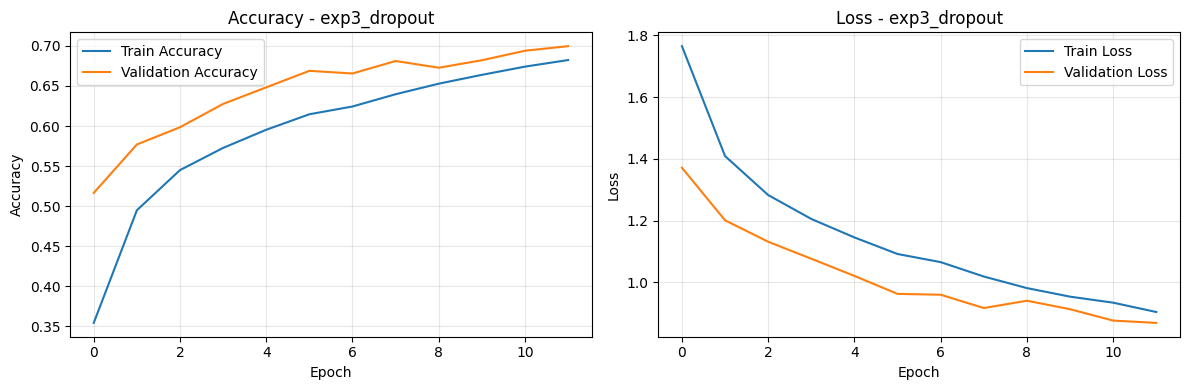

Test accuracy: 0.6936
Training time: 195.91 sec


In [34]:
exp3_history, exp3_test_loss, exp3_test_accuracy, exp3_predictions, exp3_time = train_and_evaluate(
    exp3_model,
    x_train, y_train_cat,
    x_val, y_val_cat,
    x_test, y_test_cat
)

plot_history(exp3_history, "exp3_dropout")

results.append({
    "experiment": "exp3_dropout",
    "description": "Add Dropout to reduce overfitting",
    "parameters": count_parameters(exp3_model),
    "test_loss": exp3_test_loss,
    "test_accuracy": exp3_test_accuracy,
    "best_val_accuracy": max(exp3_history.history["val_accuracy"]),
    "epochs_ran": len(exp3_history.history["loss"]),
    "training_time_sec": exp3_time
})

all_models["exp3_dropout"] = exp3_model
all_predictions["exp3_dropout"] = exp3_predictions

print("Test accuracy:", round(exp3_test_accuracy, 4))
print("Training time:", round(exp3_time, 2), "sec")

### Експеримент 4. Використання Batch Normalization

In [35]:
print("Experiment 4 - batch normalization")

exp4_model = build_model(
    filters1=32,
    filters2=64,
    activation="relu",
    use_dropout=False,
    use_batchnorm=True
)

exp4_model.summary()

Experiment 4 - batch normalization


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,994 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 448 (1.75 KB)

### Навчання моделі та аналіз результатів

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 132ms/step - accuracy: 0.5774 - loss: 1.1975 - val_accuracy: 0.2590 - val_loss: 2.6247
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.7155 - loss: 0.8282 - val_accuracy: 0.5369 - val_loss: 1.4257
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.7832 - loss: 0.6472 - val_accuracy: 0.5983 - val_loss: 1.2223
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.8366 - loss: 0.5060 - val_accuracy: 0.6088 - val_loss: 1.2438
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.8777 - loss: 0.3928 - val_accuracy: 0.6216 - val_loss: 1.2447
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.9134 - loss: 0.2952 - val_accuracy: 0.5815 - val_loss: 1.5668


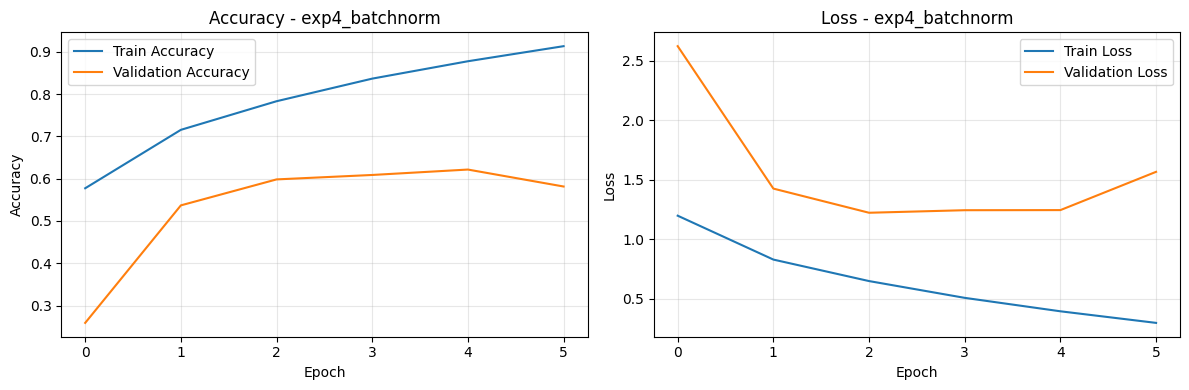

Test accuracy: 0.5907
Training time: 230.9 sec


In [36]:
exp4_history, exp4_test_loss, exp4_test_accuracy, exp4_predictions, exp4_time = train_and_evaluate(
    exp4_model,
    x_train, y_train_cat,
    x_val, y_val_cat,
    x_test, y_test_cat
)

plot_history(exp4_history, "exp4_batchnorm")

results.append({
    "experiment": "exp4_batchnorm",
    "description": "Add Batch Normalization",
    "parameters": count_parameters(exp4_model),
    "test_loss": exp4_test_loss,
    "test_accuracy": exp4_test_accuracy,
    "best_val_accuracy": max(exp4_history.history["val_accuracy"]),
    "epochs_ran": len(exp4_history.history["loss"]),
    "training_time_sec": exp4_time
})

all_models["exp4_batchnorm"] = exp4_model
all_predictions["exp4_batchnorm"] = exp4_predictions

print("Test accuracy:", round(exp4_test_accuracy, 4))
print("Training time:", round(exp4_time, 2), "sec")

--------

### Порівняльний аналіз результатів експериментів

In [37]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

results_df

,experiment,description,parameters,test_loss,test_accuracy,best_val_accuracy,epochs_ran,training_time_sec
0,exp1_more_filters,Increase number of filters: 64 and 128,1125642,0.933042,0.6957,0.7021,11,402.492177
1,exp3_dropout,Add Dropout to reduce overfitting,545098,0.873301,0.6936,0.6997,12,195.905079
2,baseline,Base CNN with ReLU,545098,0.927132,0.6843,0.6899,10,141.761044
3,exp4_batchnorm,Add Batch Normalization,545994,1.230368,0.5907,0.6216,6,230.895700
4,exp2_sigmoid,Replace ReLU with Sigmoid,545098,1.406083,0.4961,0.4935,12,212.467849


### Графік порівняння точності

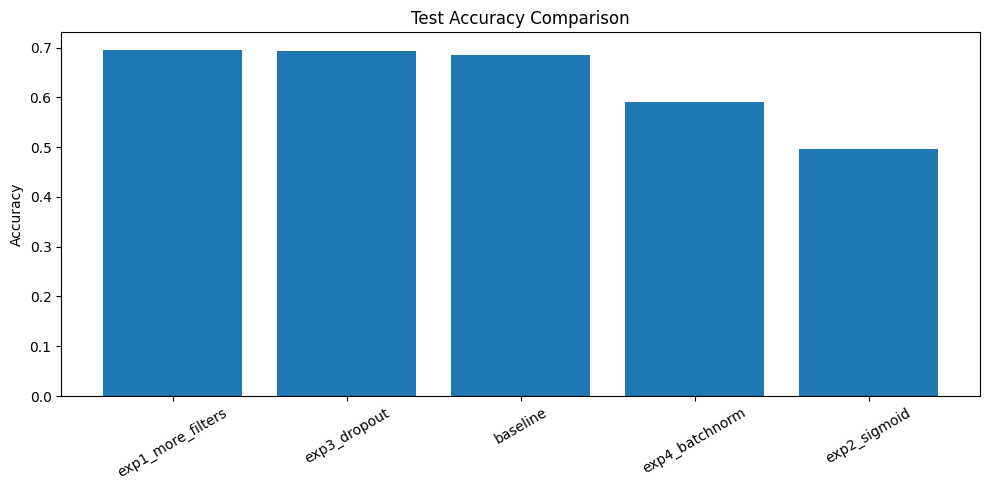

In [38]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["experiment"], results_df["test_accuracy"])
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Графік порівняння часу навчання

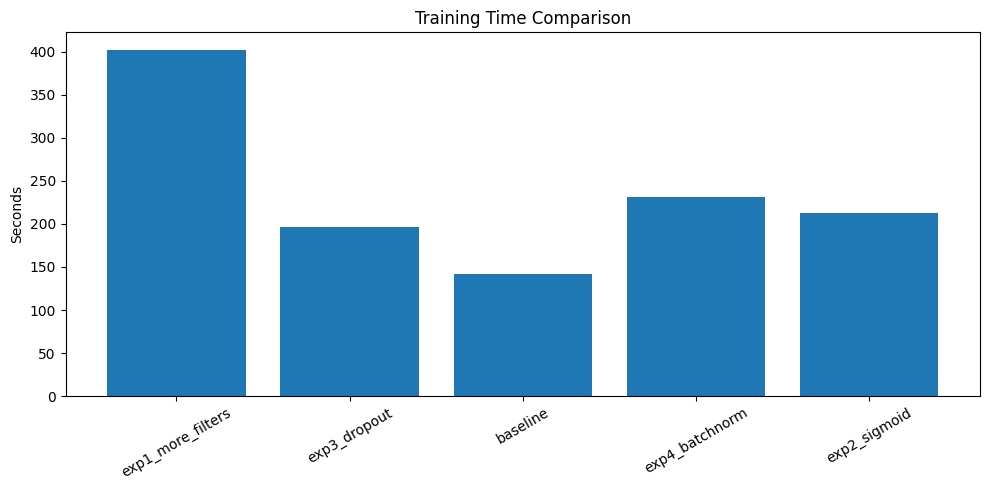

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["experiment"], results_df["training_time_sec"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Вибір найкращої моделі

In [40]:
best_experiment_name = results_df.iloc[0]["experiment"]
best_model = all_models[best_experiment_name]
best_predictions = all_predictions[best_experiment_name]

print("Best model:", best_experiment_name)
print("Best test accuracy:", round(results_df.iloc[0]["test_accuracy"], 4))

Best model: exp1_more_filters
Best test accuracy: 0.6957


### Оцінка якості найкращої моделі (Classification Report)

In [41]:
report = classification_report(
    y_test,
    best_predictions,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

    airplane     0.6857    0.7790    0.7294      1000
  automobile     0.8259    0.7780    0.8012      1000
        bird     0.6747    0.5330    0.5955      1000
         cat     0.4728    0.5900    0.5249      1000
        deer     0.6648    0.6010    0.6313      1000
         dog     0.6100    0.6130    0.6115      1000
        frog     0.8502    0.6470    0.7348      1000
       horse     0.7418    0.7900    0.7651      1000
        ship     0.7434    0.8460    0.7914      1000
       truck     0.7715    0.7800    0.7757      1000

    accuracy                         0.6957     10000
   macro avg     0.7041    0.6957    0.6961     10000
weighted avg     0.7041    0.6957    0.6961     10000



### Сonfusion matrix для найкращої моделі

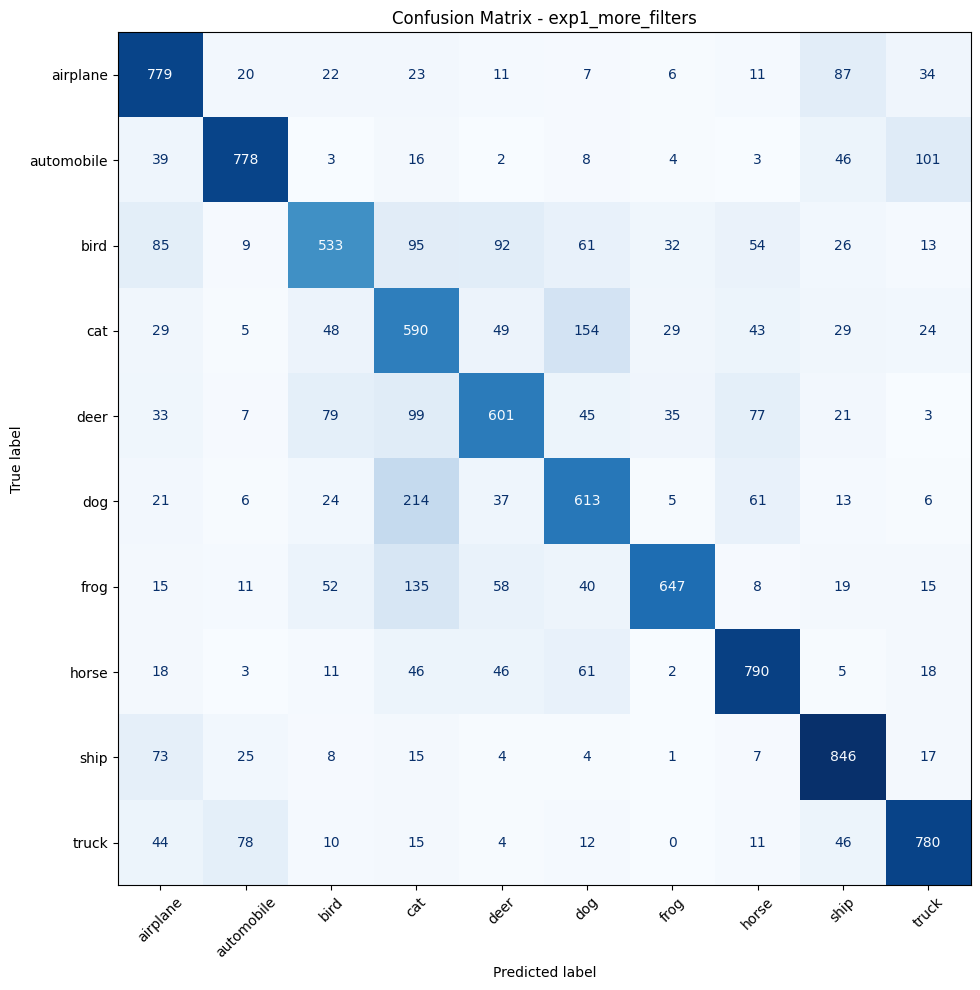

In [42]:
cm = confusion_matrix(y_test, best_predictions)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title(f"Confusion Matrix - {best_experiment_name}")
plt.tight_layout()
plt.show()

### Збереження результатів експериментів

In [ ]:
results_df.to_csv("experiments_summary.csv", index=False)
print("Таблицю збережено файлом experiments_summary.csv")

Таблицю збережено у файл experiments_summary.csv
